# CPU model setup and sanity testing

This notebook establishes the segmentation model and verifies that the training pipeline can learn. It uses a **U-Net with an ImageNet-pretrained ResNet18 encoder**, a compact GroupNorm decoder, and masked BCE + Dice loss. It does **not** run cross-validation or claim unseen-image performance.

The diagnostic intentionally memorizes images **270 and 314**, both in the training portion of frozen fold 0. Validation images **121, 241, 328 and 417** are not used for fitting or scoring in this test. Pair 278 remains excluded. No random augmentation is applied.

Implementation lives in `roof_utils/models.py`, `losses_metrics.py`, `training.py`, and `model_review.py`; the notebook imports the reusable functions. Run `python -m pip install -r requirements.txt` in your environment first. Training dependencies are pinned to PyTorch 2.8.0 and torchvision 0.23.0. The code below explicitly selects **CPU**.


In [1]:
from pathlib import Path
import sys

# Allow imports when Jupyter starts in notebooks/ without an editable install.
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
                    if (p / "roof_utils").is_dir() and (p / "pyproject.toml").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from roof_utils.config import load_paths
PATHS = load_paths(PROJECT_ROOT)

import torch
from roof_utils.model_review import run_model_tests, show_model_summary, show_sanity_results
from roof_utils.training import run_sanity_check
print("PyTorch:", torch.__version__)
print("Training device: CPU (explicit)")


PyTorch: 2.8.0
Training device: CPU (explicit)


## 1 Model architecture

The encoder produces feature maps at several resolutions. Each decoder stage upsamples the deeper features and joins them with a matching encoder feature map, recovering spatial detail. A final full-resolution stage includes the input RGB as a skip connection. The final convolution returns **one raw roof logit per pixel**, at the original image size.

Encoder BatchNorm running statistics stay fixed even during fine-tuning. The decoder uses GroupNorm so its normalization does not depend on a large batch. ImageNet normalization is applied to RGB before the model. Binary target and validity masks are not normalized.

The official pretrained encoder weights are cached under `MODELS_DIR/pretrained`; on a fresh setup, the first model creation downloads them. Checkpoints from this diagnostic are saved separately and must not be treated as production models.


In [2]:
show_model_summary(PATHS)


Architecture: U-Net with ImageNet-pretrained ResNet18 encoder
Parameters: 12,461,313
Input: (B, 3, 256, 256), ImageNet-normalized RGB
Output: (B, 1, 256, 256), raw logits
Encoder feature channels: 64 -> 64 -> 128 -> 256 -> 512
Decoder channels: 128 -> 64 -> 32 -> 16 -> 16 -> 1
Encoder BatchNorm statistics fixed; decoder uses GroupNorm.
Loss: 0.5 masked BCE + 0.5 masked soft Dice loss
Primary metric: per-image roof IoU; metrics exclude invalid pixels.
This notebook explicitly uses CPU.


## 2 Automated correctness checks

Tests cover a CPU forward/backward pass, odd image dimensions, frozen/unfrozen encoder gradients, fixed BatchNorm statistics, masked loss against a hand-computed reference, zero gradients in invalid regions, known-count IoU/Dice/precision/recall, and empty/invalid targets.

The loss is half valid-pixel mean BCE and half mean per-image soft Dice loss. Images with no valid pixels are skipped; an entirely invalid batch must be skipped rather than reported as perfect. Metrics are calculated per image over valid pixels. If both masks are empty, IoU and Dice are 1; all-invalid images are excluded.


In [3]:
run_model_tests(PATHS)


test_all_invalid_sample_does_not_change_loss (test_model_pipeline.PipelineTests.test_all_invalid_sample_does_not_change_loss) ... ok
test_forward_backward_freezing_and_batchnorm (test_model_pipeline.PipelineTests.test_forward_backward_freezing_and_batchnorm) ... ok
test_masked_loss_and_gradient (test_model_pipeline.PipelineTests.test_masked_loss_and_gradient) ... ok
test_metrics_known_counts_and_empty (test_model_pipeline.PipelineTests.test_metrics_known_counts_and_empty) ... ok

----------------------------------------------------------------------
Ran 4 tests in 0.264s

OK



## 3 Optional rerun of the two-image test

The executed CPU run is already saved. Leave `RUN_SANITY = False` to inspect it, or set it to `True` to rerun and replace this diagnostic's saved checkpoint/results.

Settings: two full 256 × 256 images per step, AdamW, weight decay 0.0001, decoder learning rate 0.001, encoder learning rate 0.00001, encoder frozen for the first 20 steps, maximum 300 steps, and evaluation every 10 steps. Stop when **each** image reaches IoU ≥ 0.95 at two consecutive evaluations. These evaluations are on the same training images, deliberately checking memorization.

The decoder learning rate remains 0.001 for this short diagnostic to test learning quickly. For subsequent cross-validation, follow the method document's lower fine-tuning decoder rate of 0.0001 and select checkpoints using validation only. Never initialize a CV run from this diagnostic checkpoint; build a fresh model from the pretrained encoder for each fold.

CPU is passed explicitly. The training code seeds Python, NumPy and PyTorch and records package versions; exact numerical reproduction across versions/hardware is not guaranteed.


In [4]:
RUN_SANITY = False
if RUN_SANITY:
    run_sanity_check(PATHS, ids=("270", "314"), device="cpu", max_steps=300, seed=42)
else:
    print("Using the saved CPU sanity results; no retraining requested.")


Using the saved CPU sanity results; no retraining requested.


## 4 Observed results

The table below shows training-set reconstruction, not validation accuracy. Red pixels in the error panels are false positives and blue pixels are missed roof pixels. Invalid regions are excluded. A checkpoint reload is compared with the original logits to check that saving and loading preserve predictions.

Outputs are stored under `REPORTS_DIR/sanity_two_images/` (`results.json`, `history.csv`, `predictions.npz`) and `MODELS_DIR/sanity_two_images/model.pt`. The configured directories come from `.env`.


Purpose: two-image memorization sanity check, NOT held-out validation
Device: cpu | steps: 50 | time: 13.6 seconds
Pass criterion: every training image reaches IoU >= 0.95 at two consecutive evaluations.
Passed: True | checkpoint reload: True
Untouched fold-0 validation IDs: ['121', '241', '328', '417']
   Image  Initial IoU    Final IoU   Final Dice
     270       0.3118       0.9634       0.9814
     314       0.1196       0.9662       0.9828

Training history (metrics measured on the same two training images):
  Step       Loss   Mean IoU  Mean Dice
     0     0.7053     0.2157     0.3445
    10     0.4269     0.8328     0.9085
    20     0.3838     0.8955     0.9447
    30     0.3524     0.9342     0.9660
    40     0.3185     0.9567     0.9778
    50     0.2894     0.9648     0.9821


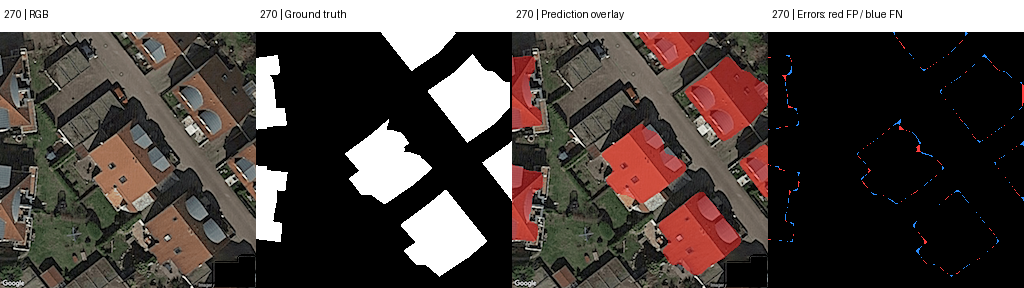

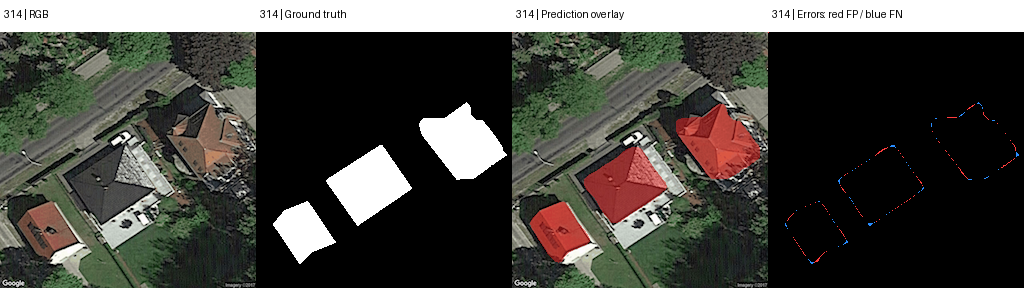


These are training-set reconstruction scores, not generalization or test accuracy.


In [5]:
result = show_sanity_results(PATHS)


## Next step

Once the correctness and memorization checks pass, train a fresh model on each of the saved development folds, first using the existing augmentation baseline and then testing mild crop/zoom on the same folds. This notebook has not performed those runs. The fixed folds are image-level development folds; geographical independence remains unverified.

References: [ResNet18 pretrained weights](https://docs.pytorch.org/vision/stable/models/generated/torchvision.models.resnet18.html), [PyTorch BCEWithLogitsLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html).
